Always import this libs:-

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt

#this line of code will show the graphs inside of the notebook, its jp notebook specific:-
%matplotlib inline 

In [2]:
def f(x):
    return (3*x**2)-(4*x)

In [3]:
f(3.0)

15.0

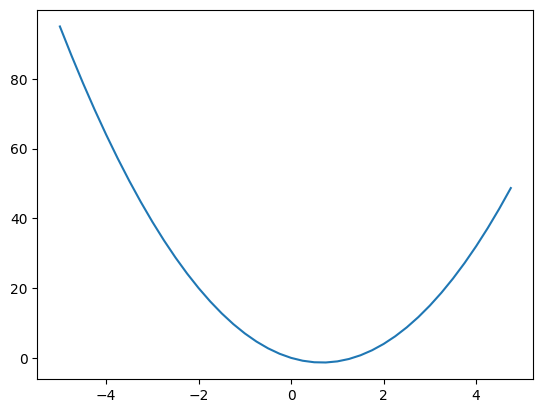

In [4]:
x_axis = np.arange(-5, 5,0.25)
y_axis = f(x_axis)
plt.plot(x_axis, y_axis)

In [ ]:
class Value:
    
    def __init__(self, data, _children=(), _op='' , label=''):
         self.data = data
         self.prev = set(_children)
         self.op = _op
         self.label = label
         self.grad = 0.0
    def __repr__(self):
         return f"Value(data={self.data})"
    
    def __add__(self, other):
         return Value(self.data + other.data, (self,other), '+')  
    def __mul__(self, other):
         return Value(self.data * other.data, (self,other), '*') 
         
a=Value(2.0, label='a')
b=Value(3.0, label='b') 
c=Value(-4.0, label='c')
d = a*b 
d.label='d'

e = d+c
e.label='e'

f = Value(2.34, label='f')

L = e*f; 
L.label='L'

print(d)

Value(data=6.0)


In [6]:
print(L.prev)
print(L.op)

{Value(data=2.0), Value(data=2.34)}
*


In [10]:
from graphviz import Digraph

def trace(root):
    """Build a set of all nodes and edges in the graph."""
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v.prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'})  # left to right

    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # value node (rounded box)
        dot.node(uid, label=f"{{ {n.label} | data: {n.data:.4f} | grad: {n.grad:.4f} }}", shape='record')
        # if this value was produced by an op, create an op node
        if n.op:
            op_uid = uid + n.op
            dot.node(op_uid, label=n.op)
            dot.edge(op_uid, uid)

    for n1, n2 in edges:
        # connect n1 to n2's op node
        dot.edge(str(id(n1)), str(id(n2)) + n2.op)

    return dot

# Forward pass
Here we have multiple inputs(a...f) and L is the output of it
In a neural network setting, this inputs would represent the weights of the neural network and we need to find the derivative of L(loss function) in respect to the weights(in this case the input vars).

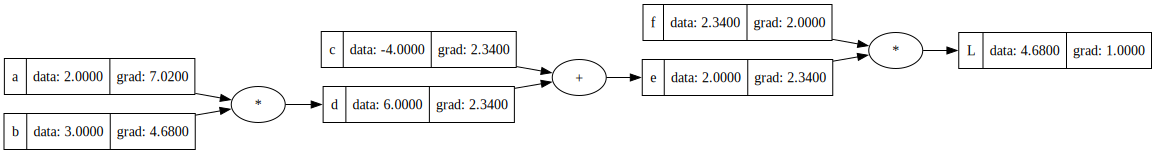

In [54]:
draw_dot(L)

# Manual Backpropogation
All we need to do is take the local derivative and multiply it backwards
- first we need to find the gradient of L with respect to L, ofc the gradient of something with respect to itself is 1
- then we need to find the grad of f with respect to L, so basically dL/df = ((f.data + h) - f)/h = 2 (after doing it using numerical derivation below)
- then we try to find the grad of e with respect to L, so basically dL/de = ((e.data + h) - f)/h = 2.3400 (numerical differentiation)
- Now to find the derivative of L with respect to c, we can use the 'Chain rule' :- dL/dc = dL/de * dL/dL
- the same Chain rule applied for the entire chain of the equation in our case :- dL/da = dL/dd * dd/da & dL/db = dL/dd * dd/db

In [58]:
h = 0.00001

def lol():    
    a=Value(2.0, label='a')
    b=Value(3.0, label='b') 
    c=Value(-4.0, label='c')
    d = a*b ; d.label='d'
    e = d+c ; e.label='e'
    f = Value(2.34, label='f')
    L = e*f; L.label='L'
    L1 = L.data 
    
    a=Value(2.0, label='a')
    b=Value(3.0, label='b') 
    c=Value(-4.0, label='c')
    d = (a*b); d.label='d'
    d.data += h
    e = d+c ; e.label='e'
    f = Value(2.34, label='f')
    L = e*f; L.label='L'
    L2 = L.data
    
    print((L2-L1)/h)
    
lol()

2.339999999900755


In [53]:
L.grad = 1
f.grad = 2.00
e.grad = 2.34
c.grad = e.grad * L.grad
d.grad = e.grad * L.grad
a.grad = d.grad * b.data  #if we derive a*b with respect to a , we get the value of = b.data
b.grad = d.grad * a.data #if we derive a*b with respect to b , we get the value of = a.data
